# **Lesson 1 - The Mathematics** 

### **1. Bell States**

In this notebook, we will dive into the mathematics behind Bell states and the quantum circuit used to create them. Bell's states or EPR pairs are the most simple examples of qubits in **quantum entanglement**. For two entangled qubits, the Bell states $\ket{\Phi^+}$ and $\ket{\Phi^-}$ are written as,

$$
\ket{\Phi^+} = \frac{1}{\sqrt{2}} (\ket{00} + \ket{11}) \quad \ket{\Phi^-} = \frac{1}{\sqrt{2}} (\ket{00} - \ket{11})
$$

The ordering of the qubits follows the little endian ordering. This means that the leftmost qubit is the most significant qubit (1st qubit) and the least significant (2nd qubit). Entanglement means the qubits are correlated with each other. $\ket{\Phi^+}$ is a superposition states where there are only two equal possibilities: Both qubits are in the `0` state or the `1` state. This means that if one of the qubits is measured in the `0` state, we _know_ that the other must also be in the same `0` state. This is also true if a qubit were to be measured in the `1` state, the other must also be in the same `1` state. We also have two other additional Bell states,

$$
\ket{\Psi^+} = \frac{1}{\sqrt{2}} (\ket{01} + \ket{10}) \quad \ket{\Psi^-} = \frac{1}{\sqrt{2}} (\ket{01} - \ket{10})
$$

These states correspond to the superposition case where observing a qubit in a state guarantees the other will be in the opposite state. Explicity, observation of a qubit in the `0` means that the other is in the `1` state and vice-versa.

### 2. Hadamard Gates

The Hadamard gate is one of the most widespread gates in quantum computing. Its purpose is to create equal superposition states. In a single qubit system where we have the standard basis $\{ \ket{0}, \ket{1} \}$, the matrix representing the Hadamard gate $\hat{H}$ takes on the following form,

$$
\hat{H} = \frac{1}{\sqrt{2}} \begin{pmatrix} 1&1 \\ 1&-1 \\  \end{pmatrix} 
$$

This is the most simplest non-trivial Hadamard matrix (normalised so that it is unitary). When applied to the states $\ket{0}$ or $\ket{1}$ it results in equal superpositions: 

### 3. CNOT Gates

### 4. The Quantum Circuit

Now we can confidently go through the calcuation of our standard quantum circuit which creates the $\ket{\Phi^+}$ Bell state,

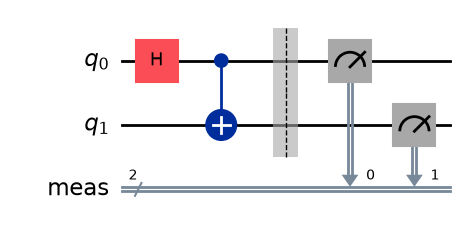

In [1]:
# Importing Qiskit libraries,
from qiskit import QuantumCircuit

# Drawing circuit,
bell_cir = QuantumCircuit(2)
bell_cir.h(0)
bell_cir.cx(control_qubit=0, target_qubit=1)
bell_cir.measure_all()
bell_cir.draw(output="mpl")

We start by preparring the first $q_0$ and second qubits $q_1$ in the state $\ket{0}$ such that our starting state is $ \ket{0} \otimes \ket{0} = \ket{00}$. Note that in the little endian convention, our second qubit comes before the first in our notation such that we have $ \ket{q_1} \otimes \ket{q_0} = \ket{q_1q_0} $. The first step is to apply a Hadamard gate $\hat{H}$ only to the first qubit $q_0$,

$$
\begin{align}
\ket{0} \otimes \hat{H}\ket{0}
&= \ket{0} \otimes \frac{\ket{0} + \ket{1}}{\sqrt{2}} \\
&= \frac{1}{\sqrt{2}} (\ket{0} \otimes \ket{0} + \ket{0} \otimes \ket{1}) \\
&= \frac{1}{\sqrt{2}} (\ket{00} + \ket{01}) 
\end{align}
$$

where the Hadmard gate $\hat{H}$ acting on the first qubit is worked out via,

$$
\begin{align}
\hat{H}\ket{0}
&= \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix} \begin{pmatrix} 1 \\ 0 \end{pmatrix} \\
&= \frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ 1 \end{pmatrix} \\
&= \frac{1}{\sqrt{2}} (\ket{0} + \ket{1})
\end{align}
$$

Alternatively, we can perform the same calculation by constructing the Hadmard gate $I \otimes \hat{H}$ (only acting upon the first qubit) as a $4 \times 4$ matrix and applying it to the entire state $\ket{00}$,

$$
\begin{align}
\Longrightarrow (I \otimes \hat{H}) \ket{00} = \underbrace{\frac{1}{\sqrt{2}} \begin{pmatrix} 1&1&0&0 \\ 1&-1&0&0 \\ 0&0&1&1 \\ 0&0&1&-1 \end{pmatrix}}_{I \otimes \hat{H}} \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix}
&= \frac{1}{\sqrt{2}} \begin{pmatrix} 1 \\ 1 \\ 0 \\ 0 \end{pmatrix} \\
&= \frac{1}{\sqrt{2}} (\ket{00} + \ket{01})
\end{align}
$$

Now the second step is to applying a CNOT (controlled NOT) gate to this intermediate state. We want the CNOT to transform $\ket{01}$ but to leave $\ket{11}$ unchanged. From our diagram, the control qubit of our CNOT gate is the first qubit while the target it the second. The input of the CNOT gate is the intermediate state. The rule of our CNOT gate is as follows: flip the target qubit if and only if the control qubit is in the state $\ket{1}$. This gives the truth table of our CNOT gate as,

$$
\begin{array}{c|c|c}
\text{Target} & \text{Control} & \text{Output} \\
\hline
\ket{0} & \ket{0} & \ket{00} \\
\ket{0} & \ket{1} & \ket{11} \\
\ket{1} & \ket{1} & \ket{01} \\
\ket{1} & \ket{0} & \ket{10}
\end{array}
$$

Constructing the $4 \times 4$ CNOT matrix responsible for this truth table, 

$$
\text{CNOT} =
\begin{pmatrix} 
1&0&0&0 \\ 
0&0&0&1 \\ 
0&0&1&0 \\ 
0&1&0&0 
\end{pmatrix}
$$

Applying the CNOT gate to the intermediate state,

$$
\begin{align}
\text{CNOT} \left[ (I \otimes \hat{H}) \ket{00} \right]
&= \text{CNOT} \left[ \frac{1}{\sqrt{2}} (\ket{00} + \ket{01}) \right] \\
&= \frac{1}{\sqrt{2}} \text{CNOT} \left[ \ket{00} + \ket{01} \right] \\
&= \frac{1}{\sqrt{2}} ( \text{CNOT}\ket{00} + \text{CNOT}\ket{01} ) \\
&= \frac{1}{\sqrt{2}} \left[ \begin{pmatrix} 1&0&0&0 \\ 0&0&0&1 \\ 0&0&1&0 \\ 0&1&0&0 \end{pmatrix} \begin{pmatrix} 1\\0\\0\\0 \end{pmatrix} + \begin{pmatrix} 1&0&0&0 \\ 0&0&0&1 \\ 0&0&1&0 \\ 0&1&0&0 \end{pmatrix} \begin{pmatrix} 0\\1\\0\\0 \end{pmatrix} \right] \\
&= \frac{1}{\sqrt{2}} \left[ \begin{pmatrix} 1\\0\\0\\0 \end{pmatrix} + \begin{pmatrix} 0\\0\\0\\1 \end{pmatrix} \right] \\
&= \frac{1}{\sqrt{2}} (\ket{00} + \ket{11}) \\
&= \ket{\Phi^+}
\end{align}
$$

We see that we recover the $\ket{\Phi^+}$ state. The final Bell state produced by the circuit is dependent on the initial state of qubit $q_0$ and $q_1$.

### References

The Most Important Gates in Quantum Computing Explained. 
IBM Technology. URL: https://www.youtube.com/watch?v=aCOsqL-jIOo